In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Instalar bibliotecas necessárias
!pip install ultralytics pytube opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
  

In [ ]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.3 MB/s eta 0:00:00


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pytube import YouTube
from google.colab import drive
from IPython.display import display, Image
import yt_dlp

In [2]:
# Montar o Google Drive para salvar os dados
drive.mount('/content/drive')

# Criar diretórios para armazenar os dados
base_dir = '/content/drive/MyDrive/padel_detection'
videos_dir = f'{base_dir}/videos'
frames_dir = f'{base_dir}/frames'

os.makedirs(videos_dir, exist_ok=True)
os.makedirs(frames_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Lista de URLs de vídeos de padel no YouTube
video_urls = [
    'https://www.youtube.com/watch?v=ELXcZ4gZATU',  # Substitua pelos URLs reais
    'https://www.youtube.com/watch?v=qxIo_Znt5AY',
    'https://www.youtube.com/watch?v=7VKfGvRm2Zc',
    'https://www.youtube.com/watch?v=bNIPvPBQ_GY',
    'https://www.youtube.com/watch?v=SKEIsCMuRPI'
]

# Função para baixar vídeos do YouTube
def download_youtube_video(url, output_path):
    try:
        # Create a unique filename based on the video ID
        video_id = url.split("watch?v=")[1] if "watch?v=" in url else url.split("/")[-1]
        output_file = os.path.join(output_path, f"{video_id}.mp4")

        ydl_opts = {
            'format': 'best[ext=mp4]',
            'outtmpl': output_file,
            'quiet': False,
            'no_warnings': False
        }

        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            print(f"Downloading: {url}")
            ydl.download([url])

        if os.path.exists(output_file):
            print(f"Successfully downloaded to {output_file}")
            return output_file
        else:
            print(f"File not found after download: {output_file}")
            return None

    except Exception as e:
        print(f"Error downloading video {url}: {e}")
        return None

In [ ]:
# Baixar os vídeos
video_paths = []
for url in video_urls:
    video_path = download_youtube_video(url, videos_dir)
    if video_path:
        video_paths.append(video_path)

print(f"Total de vídeos baixados: {len(video_paths)}")

In [ ]:
# Função para extrair frames de um vídeo
def extract_frames(video_path, output_dir, frame_interval=30):
    """
    Extrai frames de um vídeo a cada frame_interval frames.
    """
    video_name = os.path.basename(video_path).split('.')[0]
    video_frames_dir = os.path.join(output_dir, video_name)
    os.makedirs(video_frames_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            frame_path = os.path.join(video_frames_dir, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(frame_path, frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    print(f"Extraídos {saved_count} frames do vídeo {video_name}")
    return saved_count

In [ ]:
# Extrair frames de cada vídeo
total_frames = 0
for video_path in video_paths:
    frames = extract_frames(video_path, frames_dir, frame_interval=60)  # Extrair um frame a cada 2 segundos (considerando 30fps)
    total_frames += frames

print(f"Total de frames extraídos: {total_frames}")


In [ ]:
!pip install roboflow

In [ ]:
# Add this code before importing roboflow
import sys
import importlib
import types

# First, ensure pillow_heif is imported and the opener is registered
import pillow_heif
pillow_heif.register_heif_opener()

# Try to find and load the original module
try:
    # Import the original module
    from roboflow.util import image_utils as original_image_utils

    # Create a copy of the original module
    patched_module = types.ModuleType('roboflow.util.image_utils')
    patched_module.__dict__.update(original_image_utils.__dict__)

    # Remove the problematic line from the module's code
    if hasattr(patched_module, 'register_avif_opener'):
        delattr(patched_module, 'register_avif_opener')

    # Replace the module in sys.modules
    sys.modules['roboflow.util.image_utils'] = patched_module

except ImportError:
    pass  # If we can't import it yet, we'll let the normal import happen

# Now try importing Roboflow
try:
    from roboflow import Roboflow
except Exception as e:
    print(f"Error importing Roboflow: {e}")

    # If that didn't work, let's try a more direct approach
    # Find the file on disk and modify it
    import os

    # Try to find the roboflow package
    for path in sys.path:
        image_utils_path = os.path.join(path, 'roboflow', 'util', 'image_utils.py')
        if os.path.exists(image_utils_path):
            print(f"Found image_utils.py at {image_utils_path}")

            # Read the file
            with open(image_utils_path, 'r') as f:
                content = f.read()

            # Replace the problematic line
            modified_content = content.replace(
                "pillow_heif.register_avif_opener(thumbnails=False)",
                "# pillow_heif.register_avif_opener(thumbnails=False) # Disabled due to compatibility issues"
            )

            # Create a backup
            backup_path = image_utils_path + '.backup'
            with open(backup_path, 'w') as f:
                f.write(content)

            # Write the modified content
            with open(image_utils_path, 'w') as f:
                f.write(modified_content)

            print(f"Modified {image_utils_path} (backup saved to {backup_path})")

            # Clear the module from sys.modules to force a reload
            if 'roboflow.util.image_utils' in sys.modules:
                del sys.modules['roboflow.util.image_utils']
            if 'roboflow' in sys.modules:
                del sys.modules['roboflow']

            # Now try importing again
            from roboflow import Roboflow
            break

Error importing Roboflow: cannot import name 'validate_image_path' from 'roboflow.util.image_utils' (patched_image_utils.py)
Found image_utils.py at /usr/local/lib/python3.11/dist-packages/roboflow/util/image_utils.py
Modified /usr/local/lib/python3.11/dist-packages/roboflow/util/image_utils.py (backup saved to /usr/local/lib/python3.11/dist-packages/roboflow/util/image_utils.py.backup)


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="GHr9ANaYSrz0jyDxIIBp")
project = rf.workspace("objectdetection-bqixx").project("padel-player-detection-fofih")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to padel-player-detection-2 in yolov8:: 100%|██████████| 590/590 [00:00<00:00, 5497.88it/s]


In [ ]:
# Definir o diretório do dataset
dataset_dir = dataset.location  # Obtido do download do Roboflow

# Criar arquivo de configuração YAML para o treinamento
yaml_content = f"""
path: {dataset_dir}
train: train/images
val: valid/images
test: test/images

names:
  0: player
"""

yaml_path = os.path.join(dataset_dir, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Arquivo de configuração criado em {yaml_path}")

Arquivo de configuração criado em /content/padel-player-detection-2/dataset.yaml


In [ ]:
# Baixar o modelo pré-treinado YOLOv8n
model = YOLO('yolov8n.pt')
print(f"Model loaded: {model}")

Model loaded: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, t

In [ ]:
# Treinar o modelo
!yolo task=detect mode=train model=yolov8n.pt data={yaml_path} epochs=50 imgsz=640 batch=16 patience=10

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/padel-player-detection-2/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12

In [ ]:
# Carregar o modelo treinado
model_path = "runs/detect/train/weights/best.pt"
model = YOLO(model_path)

# Verificar se o modelo foi carregado corretamente
print(f"Modelo carregado: {model_path}")

Modelo carregado: runs/detect/train/weights/best.pt



image 1/1 /content/padel-player-detection-2/valid/images/stup_frame_0726_jpg.rf.fa8828e949ed243e09e2634dd18753df.jpg: 384x640 (no detections), 188.2ms
Speed: 2.6ms preprocess, 188.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Image 1: 0 detections

image 1/1 /content/padel-player-detection-2/valid/images/frame_0755_jpg.rf.aed1b09157da8705ecbb3d5e2ae76603.jpg: 384x640 3 players, 183.7ms
Speed: 2.2ms preprocess, 183.7ms inference, 6.3ms postprocess per image at shape (1, 3, 384, 640)
Image 2: 3 detections
Confidence scores: tensor([0.1237, 0.1031, 0.0691])

image 1/1 /content/padel-player-detection-2/valid/images/frame_0675_jpg.rf.50735c3eb75cd8b8d1966d2b0eb7d401.jpg: 384x640 3 players, 193.0ms
Speed: 2.2ms preprocess, 193.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Image 3: 3 detections
Confidence scores: tensor([0.0910, 0.0796, 0.0541])

image 1/1 /content/padel-player-detection-2/valid/images/ppl_campa_stup_frame_0545_jpg.rf.ffd4c912af2

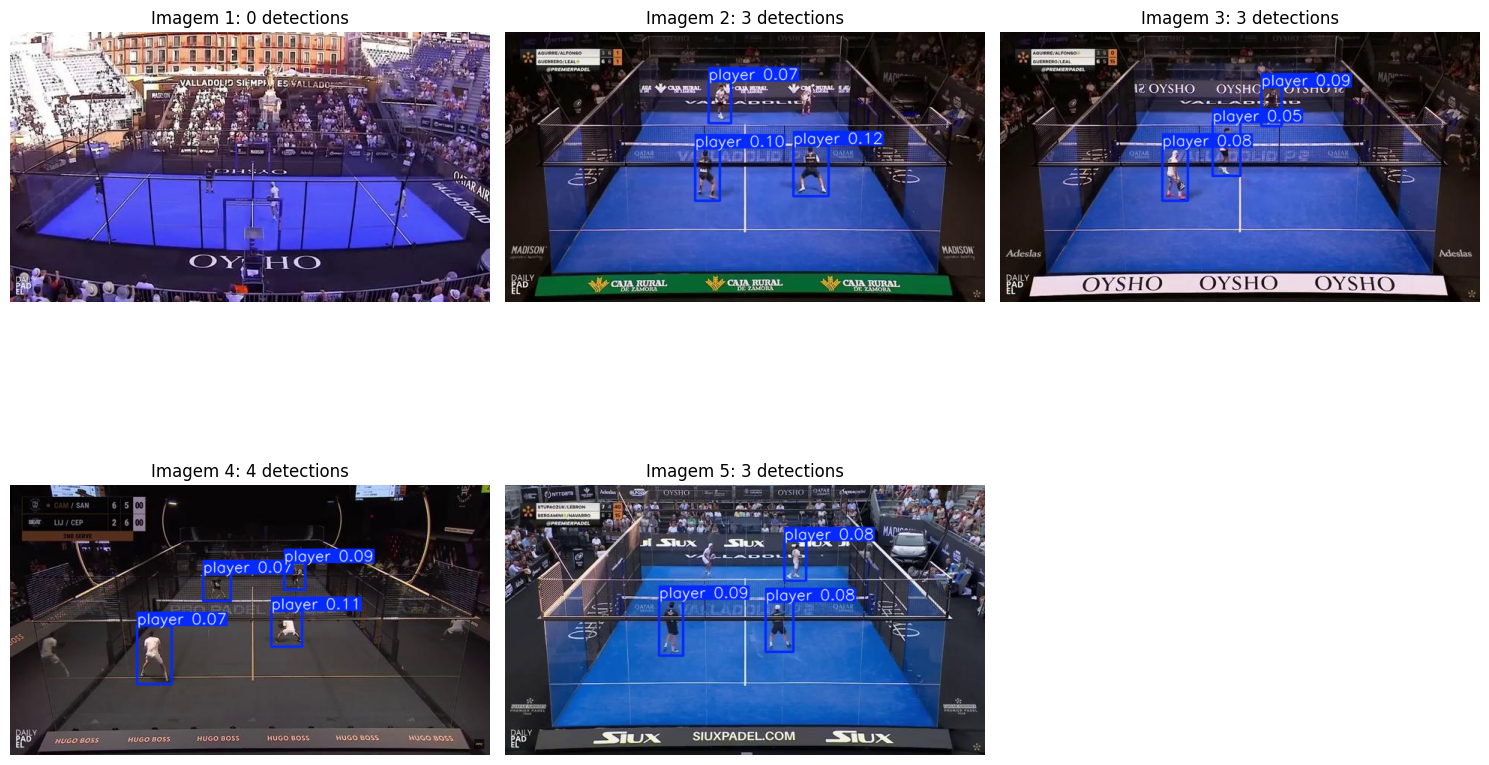

In [ ]:
val_images_dir = os.path.join(dataset_dir, 'valid/images')
test_images = os.listdir(val_images_dir)[:5]  # Testar nas primeiras 5 imagens

plt.figure(figsize=(15, 10))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(val_images_dir, img_name)
    # Set a lower confidence threshold (0.25 instead of default 0.5)
    results = model(img_path, conf=0.05)

    # Plot the image with bounding boxes
    # plt.subplot(2, 3, i+1

    # Print detection info to debug
    print(f"Image {i+1}: {len(results[0].boxes)} detections")
    if len(results[0].boxes) > 0:
        print(f"Confidence scores: {results[0].boxes.conf}")

    # Plotar a imagem com as detecções
    plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"Imagem {i+1}: {len(results[0].boxes)} detections")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Copiar o modelo para o Google Drive
model_save_path = f"{base_dir}/padel_player_detector.pt"
!cp {model_path} {model_save_path}
print(f"Modelo salvo em: {model_save_path}")

Modelo salvo em: /content/drive/MyDrive/padel_detection/padel_player_detector.pt


In [3]:
# Carregar o modelo salvo
model_path = f"{base_dir}/padel_player_detector.pt"
model = YOLO(model_path)

# Verificar se o modelo foi carregado corretamente
print(f"Modelo carregado: {model_path}")

Modelo carregado: /content/drive/MyDrive/padel_detection/padel_player_detector.pt


In [ ]:
# Testar o modelo em um vídeo
def process_video(video_path, output_path):
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Definir o codec e criar objeto VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Processar apenas 1 frame a cada 3 para acelerar
        if frame_count % 3 == 0:
            results = model(frame, conf=0.05)
            frame_with_boxes = results[0].plot()
            out.write(frame_with_boxes)
        else:
            out.write(frame)

        frame_count += 1
        if frame_count % 100 == 0:
            print(f"Processados {frame_count} frames")

    cap.release()
    out.release()
    print(f"Vídeo processado e salvo em {output_path}")

In [4]:
videos_dir = f'{base_dir}/videos'

# Get all video files in the directory
video_paths = []
for file in os.listdir(videos_dir):
    if file.endswith(('.mp4', '.avi', '.mov')):  # Add other video extensions if needed
        video_path = os.path.join(videos_dir, file)
        video_paths.append(video_path)

print(f"Found {len(video_paths)} videos")


Found 5 videos


In [7]:
def process_video_segment(video_path, output_path, start_time=0, duration=60):
    """
    Process only a segment of the video starting from start_time for duration seconds.

    Args:
        video_path: Path to input video
        output_path: Path to save processed video
        start_time: Start time in seconds
        duration: Duration to process in seconds
    """
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Calculate start frame and end frame
    start_frame = int(start_time * fps)
    end_frame = int((start_time + duration) * fps)

    # Set the frame position to start_frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = start_frame
    while cap.isOpened() and frame_count < end_frame:
        ret, frame = cap.read()
        if not ret:
            break

        # Process frame with model (every 3rd frame to speed up)
        if (frame_count - start_frame) % 3 == 0:
            results = model(frame, conf=0.05)
            frame_with_boxes = results[0].plot()
            out.write(frame_with_boxes)
        else:
            out.write(frame)

        frame_count += 1
        if frame_count % 100 == 0:
            print(f"Processed {frame_count - start_frame} frames out of {end_frame - start_frame}")

    cap.release()
    out.release()
    print(f"Video segment processed and saved to {output_path}")

In [8]:
if len(video_paths) > 0:
    test_video = video_paths[3]
    output_video = os.path.join(base_dir, 'resultado_deteccao_1min.mp4')

    # Process just one minute starting from the beginning
    process_video_segment(test_video, output_video, start_time=120, duration=30)

    # Or if you want to start from a specific time (e.g., 2 minutes into the video)
    # process_video_segment(test_video, output_video, start_time=120, duration=60)


0: 384x640 3 players, 124.4ms
Speed: 3.7ms preprocess, 124.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 142.2ms
Speed: 3.8ms preprocess, 142.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 140.7ms
Speed: 2.2ms preprocess, 140.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 121.8ms
Speed: 3.4ms preprocess, 121.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 126.8ms
Speed: 4.0ms preprocess, 126.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 130.6ms
Speed: 4.3ms preprocess, 130.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 118.7ms
Speed: 2.2ms preprocess, 118.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 117.7ms
Speed: 2.5ms preprocess, 117.7ms inference, 0.9ms postprocess per 

In [ ]:
if len(video_paths) > 0:
    test_video = video_paths[0]
    output_video = os.path.join(base_dir, 'resultado_deteccao.mp4')
    process_video(test_video, output_video)


0: 384x640 4 players, 126.6ms
Speed: 4.5ms preprocess, 126.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 players, 150.3ms
Speed: 2.4ms preprocess, 150.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 115.1ms
Speed: 2.1ms preprocess, 115.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 players, 112.1ms
Speed: 2.3ms preprocess, 112.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 players, 113.4ms
Speed: 2.1ms preprocess, 113.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 players, 117.2ms
Speed: 2.2ms preprocess, 117.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 players, 119.2ms
Speed: 2.3ms preprocess, 119.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 118.3ms
Speed: 2.9ms preprocess, 118.3ms inference, 0.9ms postprocess per 

In [13]:
def process_video_segment_tracking(video_path, output_path, start_time=120, duration=30):
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Definir o codec e criar objeto VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Calcular frames de início e fim
    start_frame = int(start_time * fps)
    end_frame = None if duration is None else int((start_time + duration) * fps)

    # Posicionar no frame inicial
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Inicializar o tracker - usar API moderna do OpenCV
    tracker = cv2.TrackerKCF_create() if hasattr(cv2, 'TrackerKCF_create') else None

    # Se a API moderna não estiver disponível, tentar a API mais recente
    if tracker is None:
        try:
            tracker = cv2.TrackerKCF.create()
        except:
            # Se nenhuma API de tracking estiver disponível, usar apenas detecção
            print("Aviso: APIs de tracking não disponíveis, usando apenas detecção")
            tracker = None

    tracking_initialized = False
    tracking_box = None

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Verificar se atingiu o fim do segmento
        current_frame = start_frame + frame_count
        if end_frame is not None and current_frame >= end_frame:
            break

        # Realizar detecção a cada 30 frames ou no início
        if frame_count % 30 == 0 or not tracking_initialized:
            results = model(frame, conf=0.05)
            detections = results[0].boxes.xyxy.cpu().numpy()

            if len(detections) > 0:
                # Reiniciar trackers com as novas detecções
                tracking_initialized = False
                frame_with_boxes = results[0].plot()

                if tracker is not None:
                    # Inicializar tracker com a detecção mais confiante
                    best_detection = detections[0]  # Assumindo que a primeira é a mais confiante
                    tracking_box = (int(best_detection[0]), int(best_detection[1]),
                                   int(best_detection[2] - best_detection[0]),
                                   int(best_detection[3] - best_detection[1]))

                    # Recriar o tracker para cada nova inicialização
                    tracker = cv2.TrackerKCF_create() if hasattr(cv2, 'TrackerKCF_create') else cv2.TrackerKCF.create()
                    tracker.init(frame, tracking_box)
                    tracking_initialized = True
            else:
                frame_with_boxes = frame
        else:
            # Usar tracking nos frames intermediários
            if tracking_initialized and tracker is not None:
                success, tracking_box = tracker.update(frame)
                if success:
                    x, y, w, h = [int(v) for v in tracking_box]
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    frame_with_boxes = frame
                else:
                    tracking_initialized = False
                    frame_with_boxes = frame
            else:
                frame_with_boxes = frame

        out.write(frame_with_boxes)
        frame_count += 1
        if frame_count % 100 == 0:
            print(f"Processados {frame_count} frames (total: {current_frame})")

    cap.release()
    out.release()
    print(f"Vídeo processado e salvo em {output_path}")
    print(f"Segmento: {start_time}s até {start_time + (duration if duration else (frame_count/fps))}s")

In [15]:
if len(video_paths) > 0:
    test_video = video_paths[3]
    output_video = os.path.join(base_dir, 'resultado_deteccao_tracking.mp4')
    process_video_segment_tracking(test_video, output_video, 120, 30)

Aviso: APIs de tracking não disponíveis, usando apenas detecção

0: 384x640 3 players, 130.6ms
Speed: 4.1ms preprocess, 130.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 124.4ms
Speed: 2.0ms preprocess, 124.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 128.2ms
Speed: 3.2ms preprocess, 128.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 145.5ms
Speed: 3.8ms preprocess, 145.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 119.7ms
Speed: 2.4ms preprocess, 119.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 124.5ms
Speed: 3.4ms preprocess, 124.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 128.6ms
Speed: 3.6ms preprocess, 128.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 players, 134.2ms
Sp